# *Aufgabe: Gradientenverfahren*

0. Importieren Sie alle die nötigen Bibliotheken.

In [1]:
import pandas as pd
import numpy as np
from time import time
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# Importieren Sie die Bibliotheken für die Modelle und die Visualisierung

1. Implementieren Sie auf Grundlage eines linearen Modells für Regressionen das Gradientenverfahren. Verwenden Sie die gleichen Daten wie in Aufgabe Modul 4:

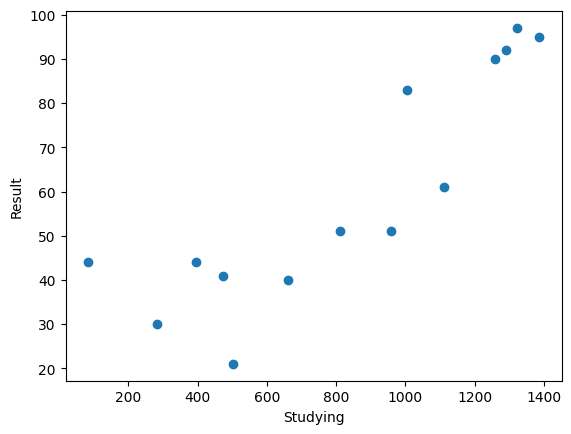

In [26]:
studying = np.array(
    [84, 1323, 282, 957, 1386, 810, 396, 474, 501, 660, 1260, 1005, 1110, 1290]
)
result = np.array([44, 97, 30, 51, 95, 51, 44, 41, 21, 40, 90, 83, 61, 92])

plt.scatter(studying, result)
plt.xlabel("Studying")
plt.ylabel("Result")
plt.show()

Errechnen Sie dafür den Fehler (MSE / SSE) in jede Iteration und passen Sie die Gewichte Ihres Modells auf dessen Grundlage an. Zusatzaufgabe: fügen Sie auch das Bias hinzu.

2862.985947258323


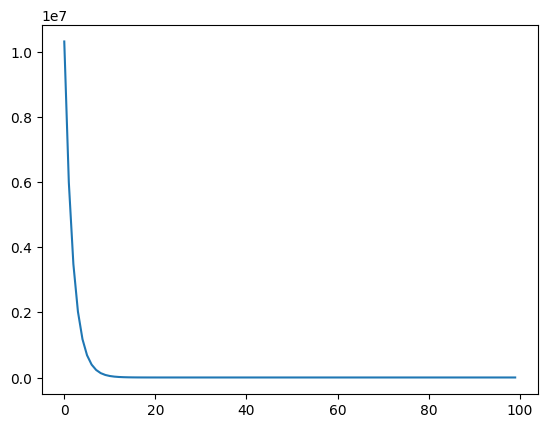

In [ ]:
# Initialgewicht
w = 1
#b = 1
# Anzahl der Epochen:
epoch = 500
# Learning rate:
lr_w = 0.00000001
#lr_b = 0.03


# Vergesses Sie nicht, den Fehler bei jeder Iteration für die Visualisierung zu speichern

# Gehen Sie durch alle Epochen und Berechnen sie das neue Gewicht anhand des Gradientens
#SSE definieren
def sse(y_pred, y):
    return np.sum((y_pred-y)**2)

#Startgewicht zufällig wählen

ws=[]
#bs=[]
errors = []
for epoch in range(100):
    predicted = w * studying #+b
    error = sse(predicted, result)
    errors.append(error)
    gradient_w = 2*np.dot(studying,predicted-result)
    gradient_b = 2*np.sum(predicted-result)
    w=w-lr_w*gradient_w
    #b=b-lr_b*gradient_b
    ws.append(w)
    #bs.append(b)

#plt.plot(bs)
#plt.show()
print(error)
plt.plot(errors)
plt.show()

31844.706571291572


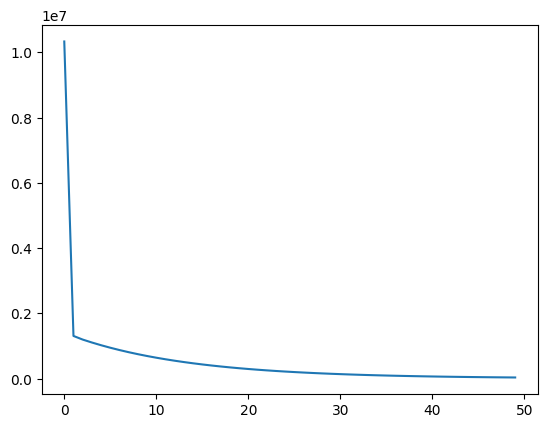

In [49]:
# Initialgewicht
w = 1
b = 1
# Anzahl der Epochen:
epoch = 50
# Learning rate:
lr_w = 0.00000001
lr_b = 0.03


# Vergesses Sie nicht, den Fehler bei jeder Iteration für die Visualisierung zu speichern


# Gehen Sie durch alle Epochen und Berechnen sie das neue Gewicht anhand des Gradientens
# SSE definieren
def sse(y_pred, y):
    return np.sum((y_pred - y) ** 2)


# Startgewicht zufällig wählen
w = 1
ws = []
bs = []
errors = []
for epoch in range(epoch):
    predicted = w * studying + b
    error = sse(predicted, result)
    errors.append(error)
    gradient_w = 2 * np.dot(studying, predicted - result)
    gradient_b = 2 * np.sum(predicted - result)
    w = w - lr_w * gradient_w
    b = b - lr_b * gradient_b
    ws.append(w)
    bs.append(b)

# plt.plot(bs)
# plt.show()
print(error)
plt.plot(errors)
plt.show()


In [ ]:

def gradient_descent(x, w, y, epochs=500, lr=0.00000001):
    # Für Plots speichern wir alle "zwischendrin" Fehler und Gewichte
    w_history, error_history = [w], []
    # Mehrere Epochen trainieren
    for _ in tqdm(range(epochs)):
        # Der aktuelle Fehler und das aktuelle Gewicht werden gespeichert
        error_history.append(sse(x, w, y))
        w_history.append(w)

        w_update = []
        # Für jedes einzelne Gewicht
        for i in range(len(w)):
            gradient = np.sum(2 * x[:, i : i + 1] * (np.dot(x, w).reshape(-1, 1) - y))
            # das alte Gewicht w
            w_update.append(w[i] - lr * gradient)

        # Die alten Gewichte werden durch die neuen ersetzt
        w = np.array(w_update)

    # Optimierte Gewichte und "zwischendrin" Fehler und Gewichte zurückgeben
    return w, np.array(error_history), np.squeeze(np.array(w_history))


# Prepare the input data with bias term
x = np.column_stack([studying, np.ones(len(studying))])
y = result.reshape(-1, 1)


Zeigen Sie, dass Sie nach einer gewissen Anzahl Epochen (Iterationen) den Fehler Ihres Modells minimiert haben. 

Zusatzaufgabe 1. Implementieren Sie ein Momentum für Ihr Gradientenverfahren

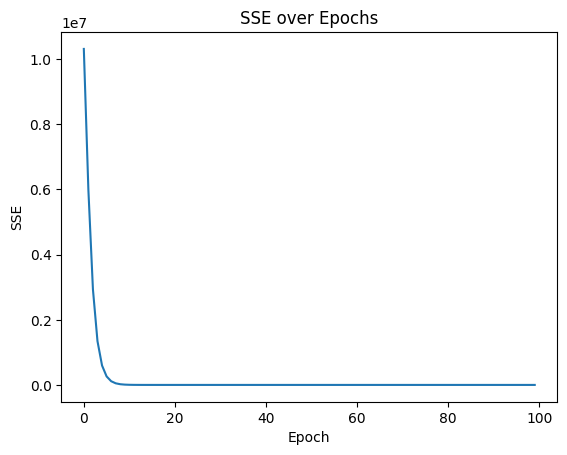

2862.985947258323


In [47]:
# Initialgewicht
w = 1
# Anzahl der Epochen:
epoch = 500
# Learning rate:
lr = 0.00000001


# Vergesses Sie nicht, den Fehler bei jeder Iteration für die Visualisierung zu speichern
# Gehen Sie durch alle Epochen und Berechnen sie das neue Gewicht anhand des Gradientens
# SSE definieren
def sse(y_pred, y):
    return np.sum((y_pred - y) ** 2)


# Startgewicht zufällig wählen
w_random = np.array([-10, 15]).reshape(-1, 1)
w = 1
momentum = 0.2
last_velocity = 0
ws = []
errors = []
for epoch in range(100):
    predicted = w * studying
    error = sse(predicted, result)
    errors.append(error)
    # print(f"Epoch {epoch}: w={w}, error={error}")
    gradient = 2 * np.dot(studying, predicted - result)
    velocity = (momentum * last_velocity) - (lr * gradient)
    w = w + velocity
    ws.append(w)
    last_velocity = velocity

plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("SSE")
plt.title("SSE over Epochs")
plt.show()
print(error)


  0%|          | 0/500 [00:00<?, ?it/s]

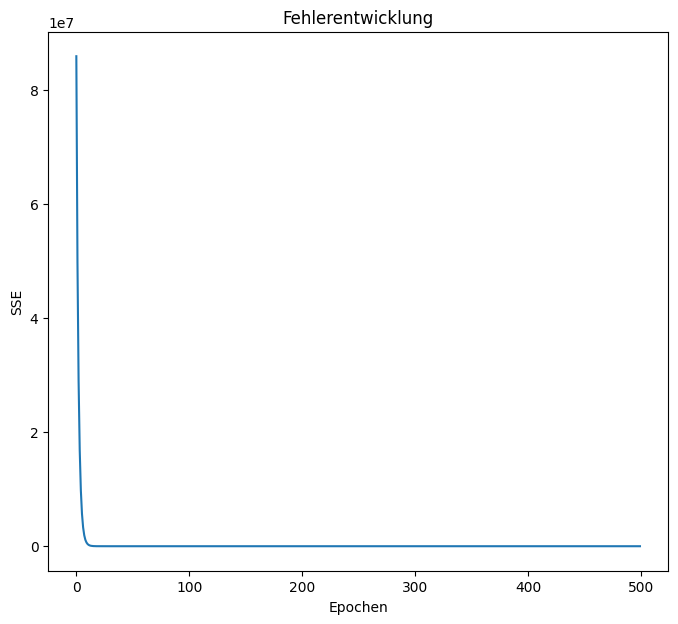

In [ ]:
# Fahren Sie fort wie in der letzten Aufgabe, aber ergänzen Sie die Formel durch das Momentum
w_random = np.array([-10, 15]).reshape(-1, 1)

def gradient_descent_with_momentum(x, w, y, epochs=500, lr=0.00000001, momentum=0.2):
    # Für Plots speichern wir alle "zwischendrin" Fehler und Gewichte
    w_history, error_history = [w], []
    last_velocity = [0, 0]
    times = []
    # Mehrere Epochen trainieren
    for _ in tqdm(range(epochs)):
        # Der aktuelle Fehler und das aktuelle Gewicht werden gespeichert
        error_history.append(sse(x, w, y))
        w_history.append(w)
        w_update = []
        # Für jedes einzelne Gewicht
        for i in range(len(w)):
            gradient = np.sum(2 * x[:, i : i + 1] * (np.dot(x, w).reshape(-1, 1) - y))
            velocity = (momentum * last_velocity[i]) - (lr * gradient)
            w_update.append(w[i] + velocity)
            last_velocity[i] = velocity

        # Die alten Gewichte werden durch die neuen ersetzt
        w = np.array(w_update)

    # Optimierte Gewichte und "zwischendrin" Fehler und Gewichte zurückgeben
    return w, np.array(error_history), np.squeeze(np.array(w_history)), times


w_optimized, error_history, w_history = gradient_descent(x, w_random, y, lr=0.00000001)

fig = plt.figure(figsize=(8, 7))
plt.title("Fehlerentwicklung")
plt.xlabel("Epochen")
plt.ylabel("SSE")
plt.plot(error_history)
plt.show()

Zusatzaufgabe 2: Wiederholen Sie den Schritt 2 für die Logistische Regression. 

In [1]:
# Beachten Sie was bei der logitischen Regression im Vergleich zur linearen Regression angepasst werden muss.